In [889]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [890]:
training_set_path = "train.csv"
data = pd.read_csv(training_set_path)
data.shape

(1460, 81)

In [891]:
data.sample(4)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
85,86,60,RL,121.0,16059,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,260000
1244,1245,70,RL,NaN,11435,Pave,NaN,IR1,HLS,AllPub,...,0,NaN,NaN,NaN,0,6,2006,WD,Normal,230000
409,410,60,FV,85.0,10800,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,New,Partial,339750
188,189,90,RL,64.0,7018,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Alloca,153337


In [892]:
# Investigating datatypes of variable values
data.iloc[:, 0:50].dtypes

Id                int64
MSSubClass        int64
MSZoning         object
LotFrontage     float64
LotArea           int64
Street           object
Alley            object
LotShape         object
LandContour      object
Utilities        object
LotConfig        object
LandSlope        object
Neighborhood     object
Condition1       object
Condition2       object
BldgType         object
HouseStyle       object
OverallQual       int64
OverallCond       int64
YearBuilt         int64
YearRemodAdd      int64
RoofStyle        object
RoofMatl         object
Exterior1st      object
Exterior2nd      object
MasVnrType       object
MasVnrArea      float64
ExterQual        object
ExterCond        object
Foundation       object
BsmtQual         object
BsmtCond         object
BsmtExposure     object
BsmtFinType1     object
BsmtFinSF1        int64
BsmtFinType2     object
BsmtFinSF2        int64
BsmtUnfSF         int64
TotalBsmtSF       int64
Heating          object
HeatingQC        object
CentralAir      

In [893]:
data.iloc[:, 50:81].dtypes

HalfBath           int64
BedroomAbvGr       int64
KitchenAbvGr       int64
KitchenQual       object
TotRmsAbvGrd       int64
Functional        object
Fireplaces         int64
FireplaceQu       object
GarageType        object
GarageYrBlt      float64
GarageFinish      object
GarageCars         int64
GarageArea         int64
GarageQual        object
GarageCond        object
PavedDrive        object
WoodDeckSF         int64
OpenPorchSF        int64
EnclosedPorch      int64
3SsnPorch          int64
ScreenPorch        int64
PoolArea           int64
PoolQC            object
Fence             object
MiscFeature       object
MiscVal            int64
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
dtype: object

In [894]:
# Dropping "Id" column
data = data.drop('Id', axis = 1)

<Axes: xlabel='SalePrice', ylabel='Count'>

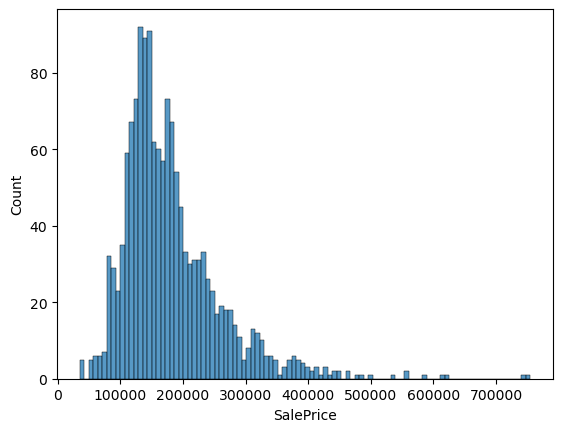

In [895]:
# Plotting distribution of the dependent variable
sns.histplot(data['SalePrice'], bins = 100)

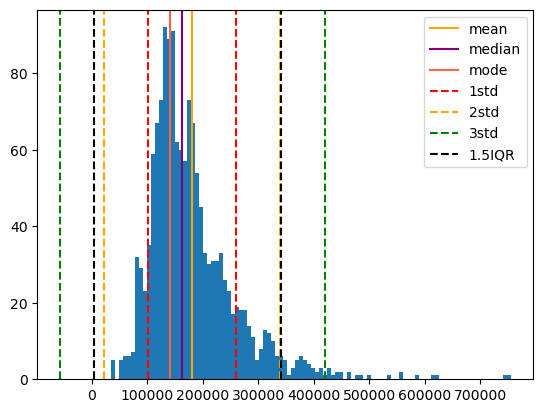

In [896]:
# Plotting the distribution of the dependent variable with mean, median, mode and standard deviations on the graph

muprice = data['SalePrice'].mean()
stdprice = data['SalePrice'].std()

low_3sprice = muprice - 3 * stdprice
up_3sprice = muprice + 3 * stdprice

q1price = data['SalePrice'].quantile(0.25)
q3price = data['SalePrice'].quantile(0.75)
iqrprice = q3price - q1price

low_iqrprice = q1price - iqrprice * 1.5
up_iqrprice = q3price + iqrprice * 1.5


low_1s = muprice - 1 * stdprice
up_1s = muprice + 1 * stdprice


low_2s = muprice - 2 * stdprice
up_2s = muprice + 2 * stdprice

plt.hist(data['SalePrice'], bins=100)

plt.axvline(muprice, linestyle='-', c='orange', label='mean')
plt.axvline(data['SalePrice'].median(), linestyle='-', c='purple', label='median')
plt.axvline(data['SalePrice'].mode()[0], linestyle='-', c='tomato', label='mode')

plt.axvline(low_1s, linestyle='--', c='red',   label='1std')
plt.axvline(up_1s,  linestyle='--', c='red')


plt.axvline(low_2s, linestyle='--', c='orange',   label='2std')
plt.axvline(up_2s,  linestyle='--', c='orange')

plt.axvline(low_3sprice, linestyle='--', c='green',   label='3std')
plt.axvline(up_3sprice,  linestyle='--', c='green')


plt.axvline(low_iqrprice, linestyle='--', c='black',   label='1.5IQR')
plt.axvline(up_iqrprice,  linestyle='--', c='black')


plt.legend(loc='upper right')
plt.savefig("picture1.png")
plt.show()

In [897]:
# Checking number of outliers for 3std threshold
price_outliers = pd.DataFrame({'SalePrice Outliers': [len(data[(data['SalePrice'] < low_3sprice) | (data['SalePrice'] > up_3sprice)])]})
price_outliers

,SalePrice Outliers
0,22


In [898]:
# Checking how many outliers there are above the 3std-threshold
price_outliers = pd.DataFrame({'SalePrice Outliers': [len(data[(data['SalePrice'] > up_3sprice)])]})
price_outliers

,SalePrice Outliers
0,22


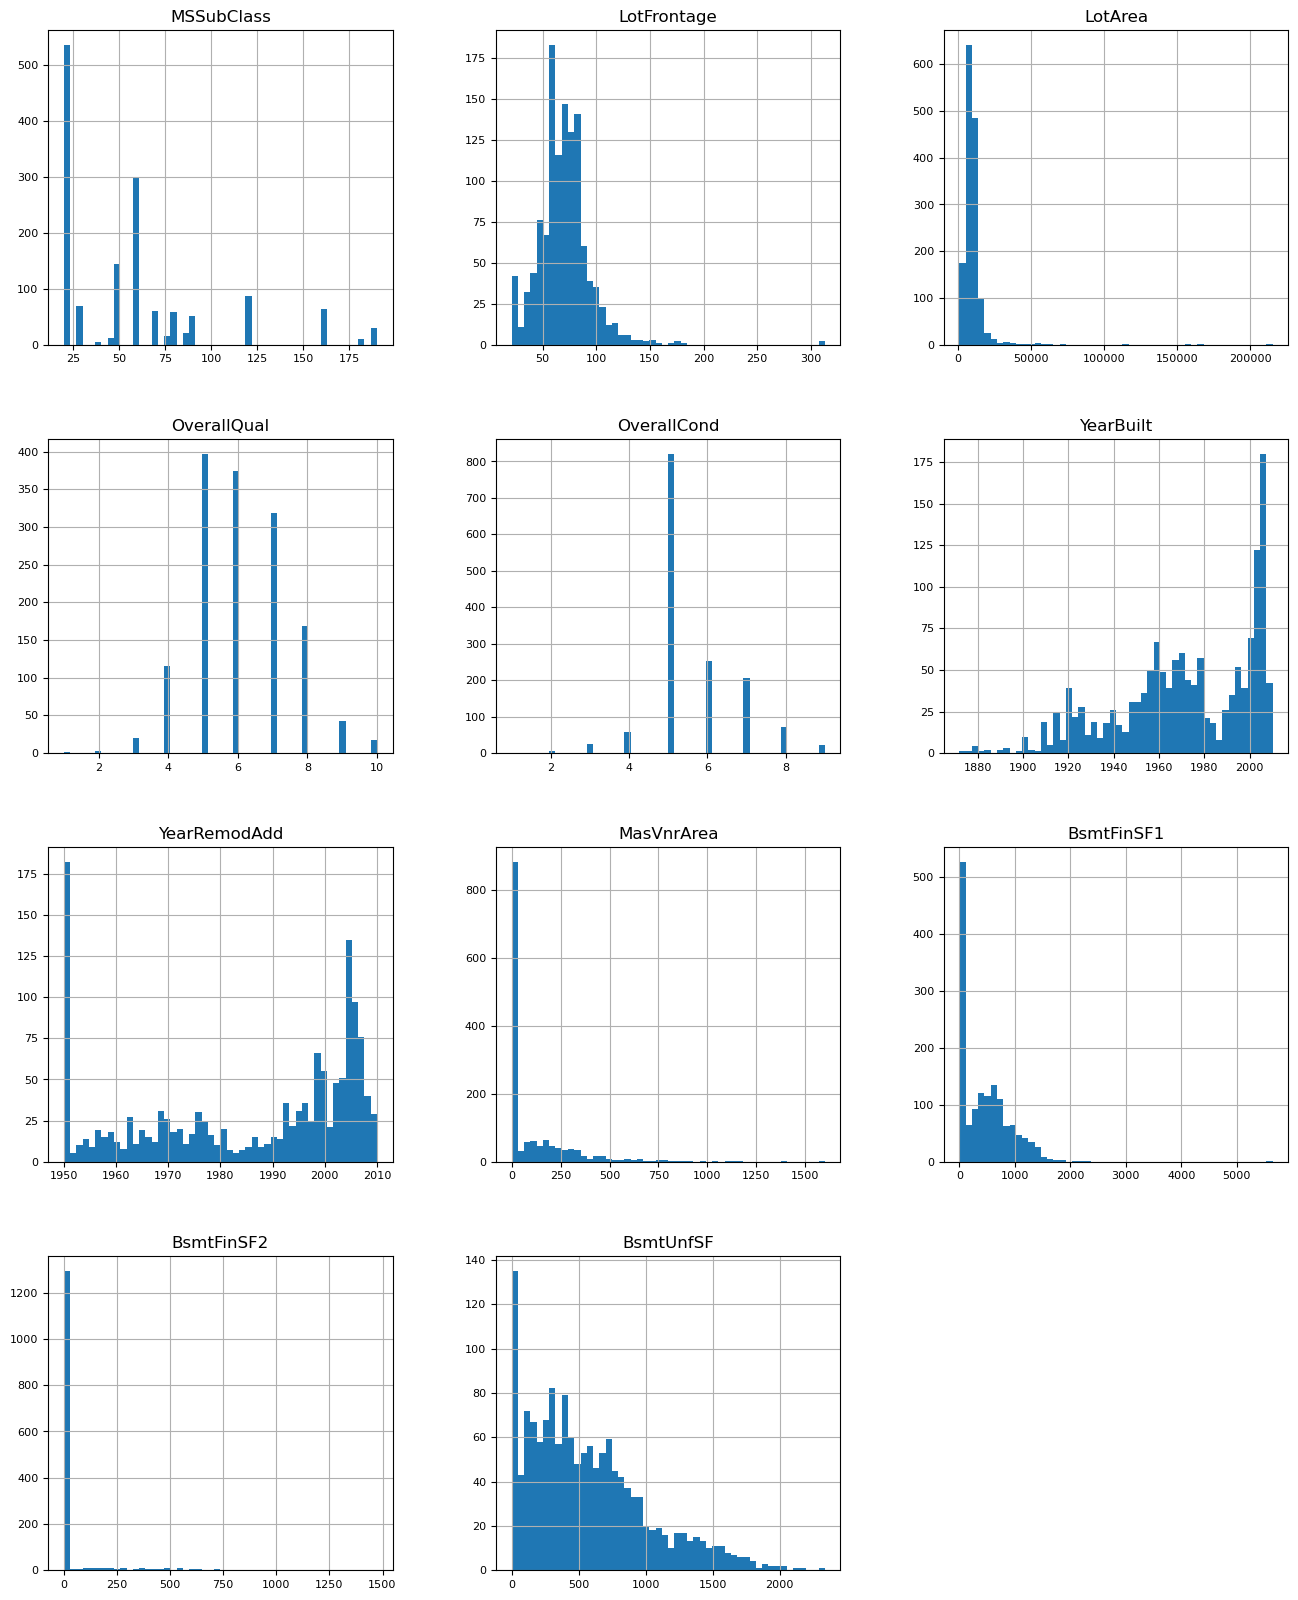

In [899]:
data_numerical_set_1 = data[['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF']]
data_numerical_set_1.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8);
# plt.savefig("picture2.png")

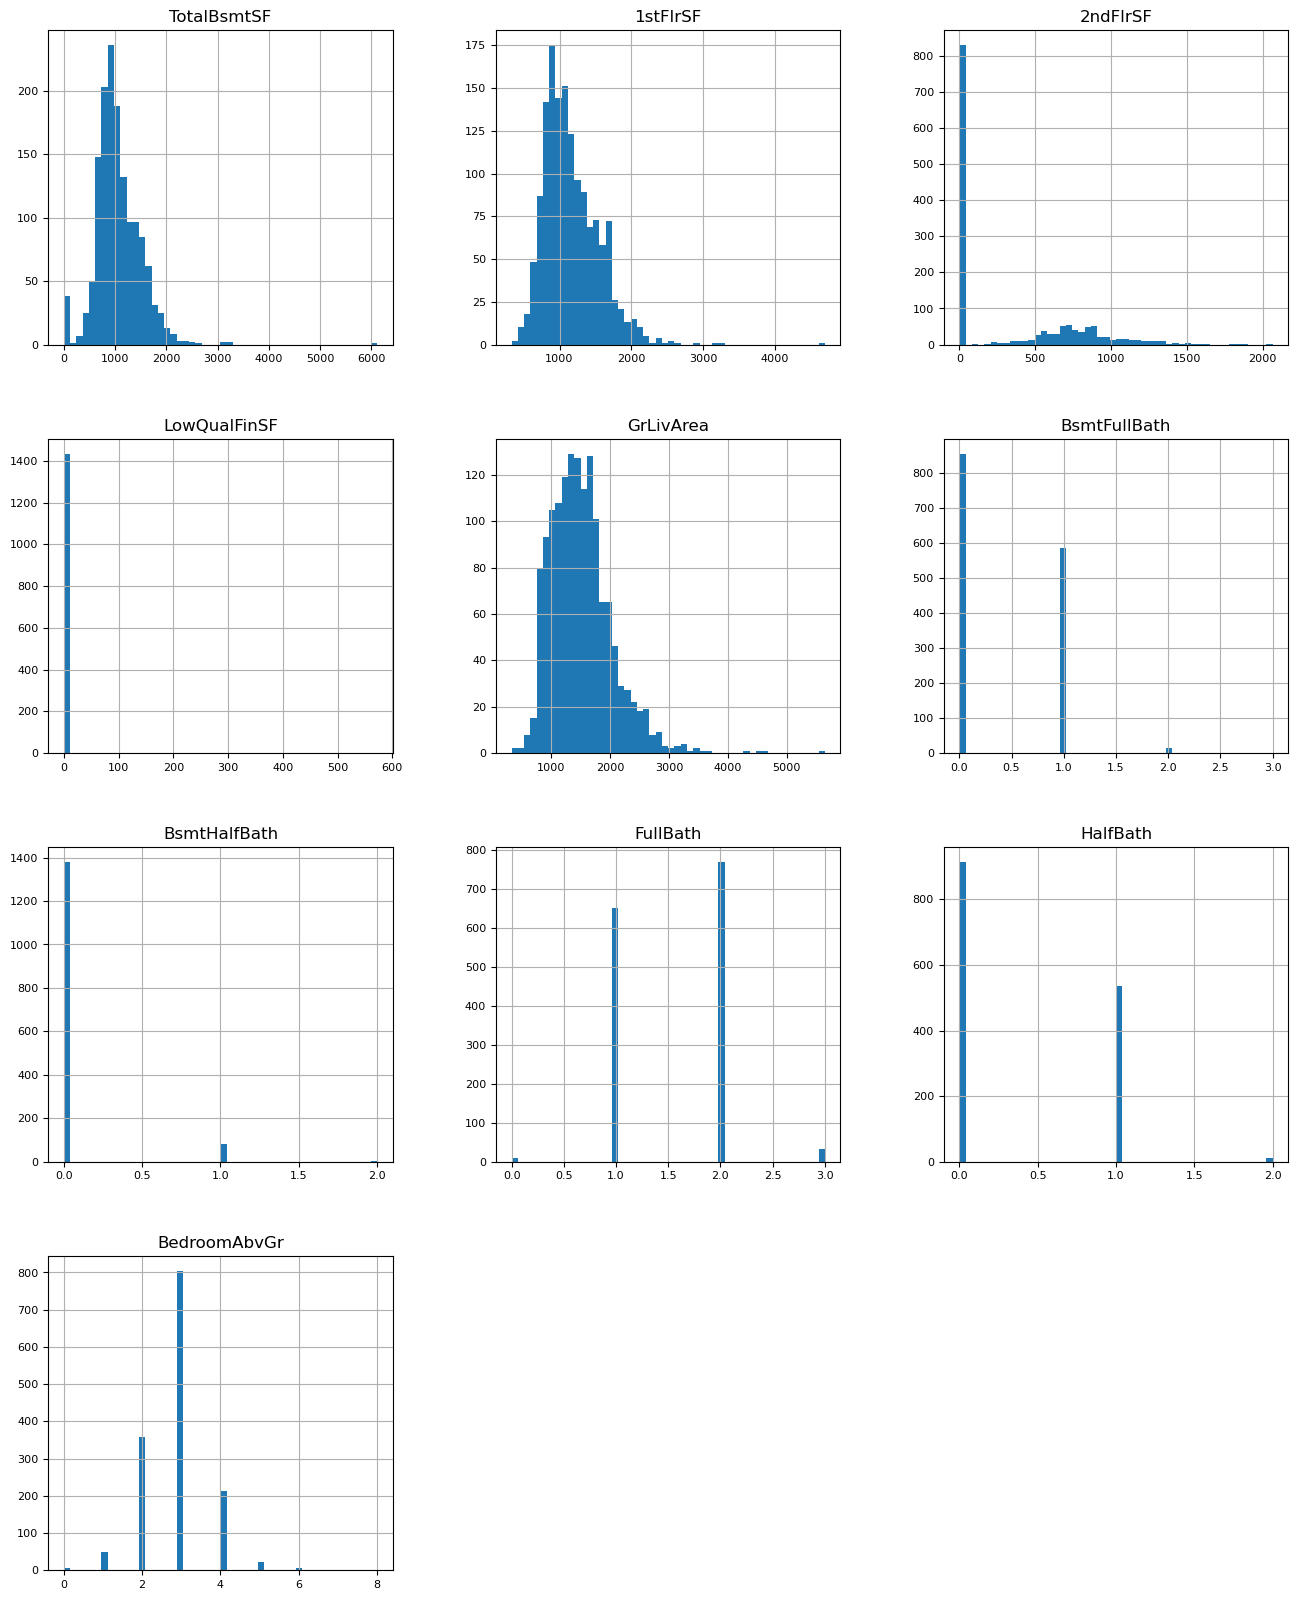

In [900]:
data_numerical_set_2 = data[['TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea','BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr']]
data_numerical_set_2.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8);
# plt.savefig("picture3.png")

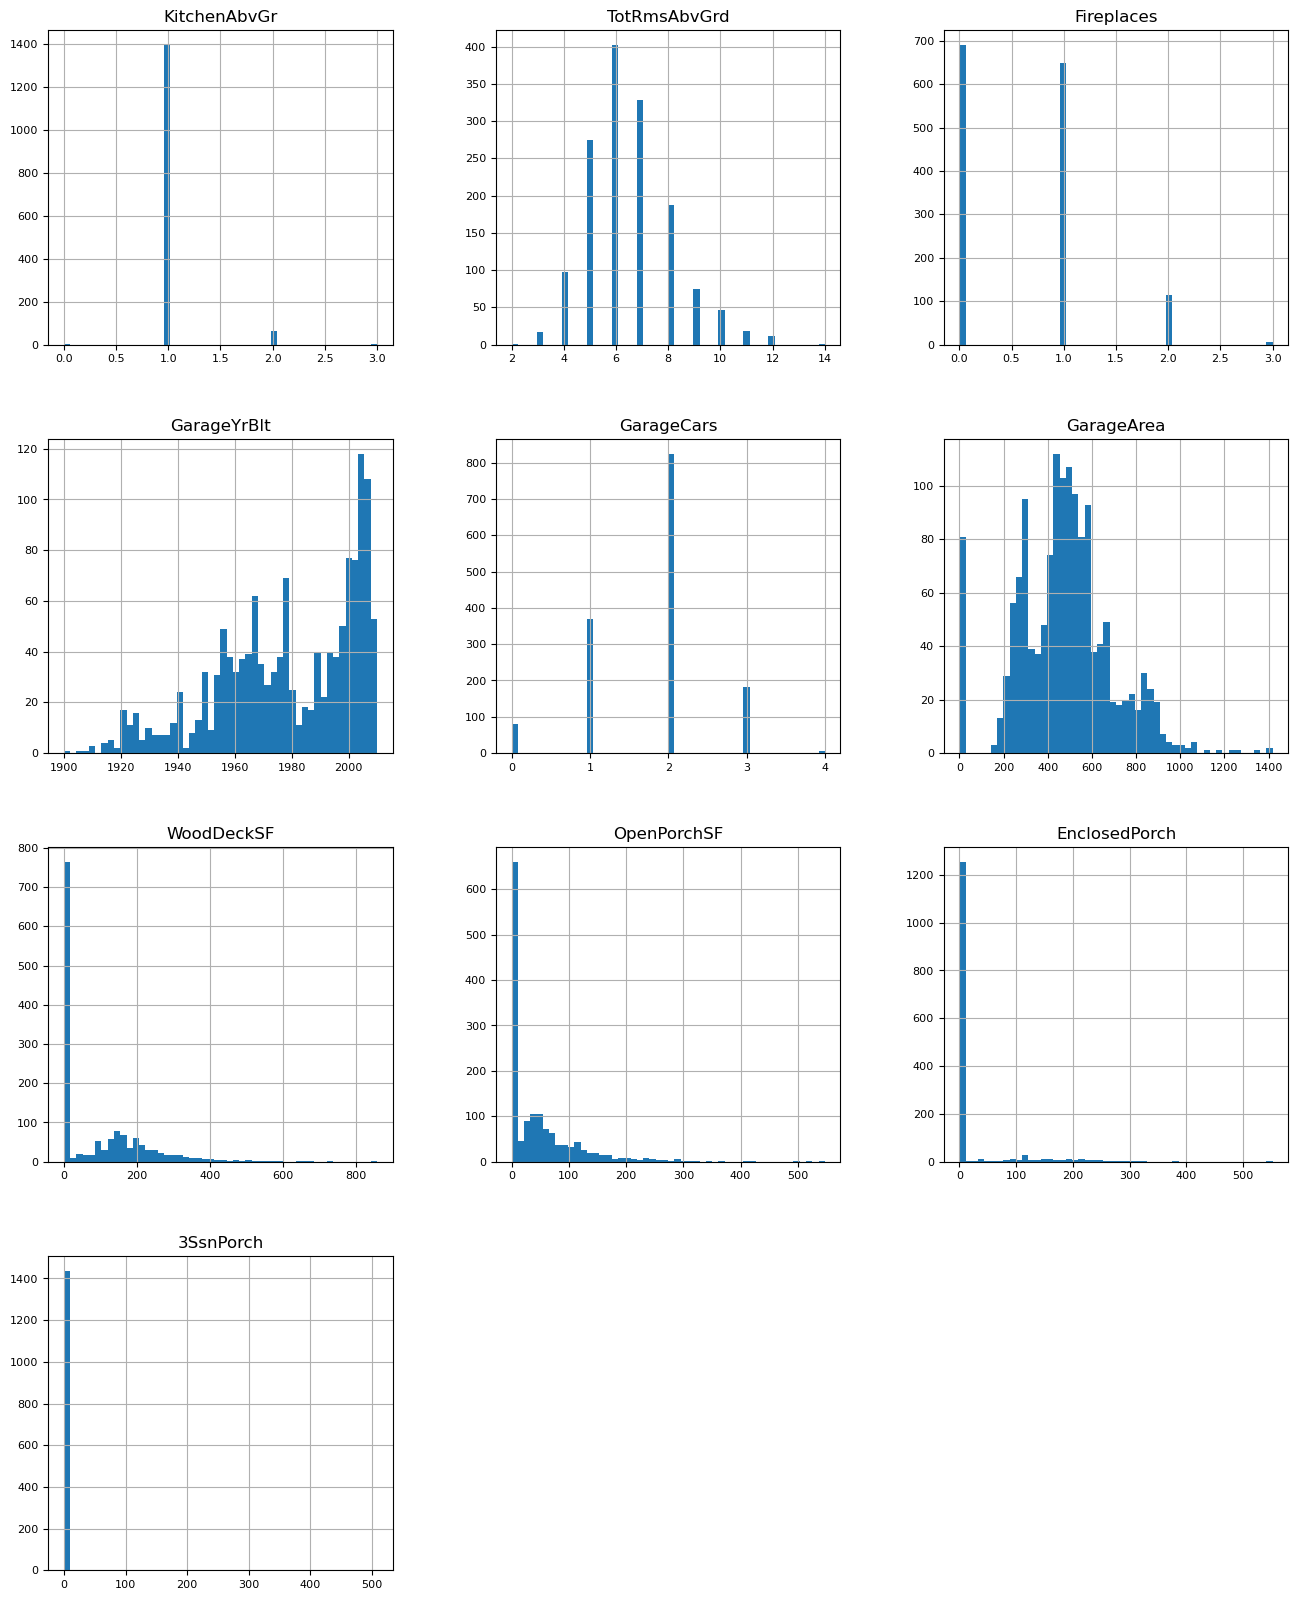

In [901]:
data_numerical_set_3 = data[['KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch']]
data_numerical_set_3.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8);
# plt.savefig("picture4.png")

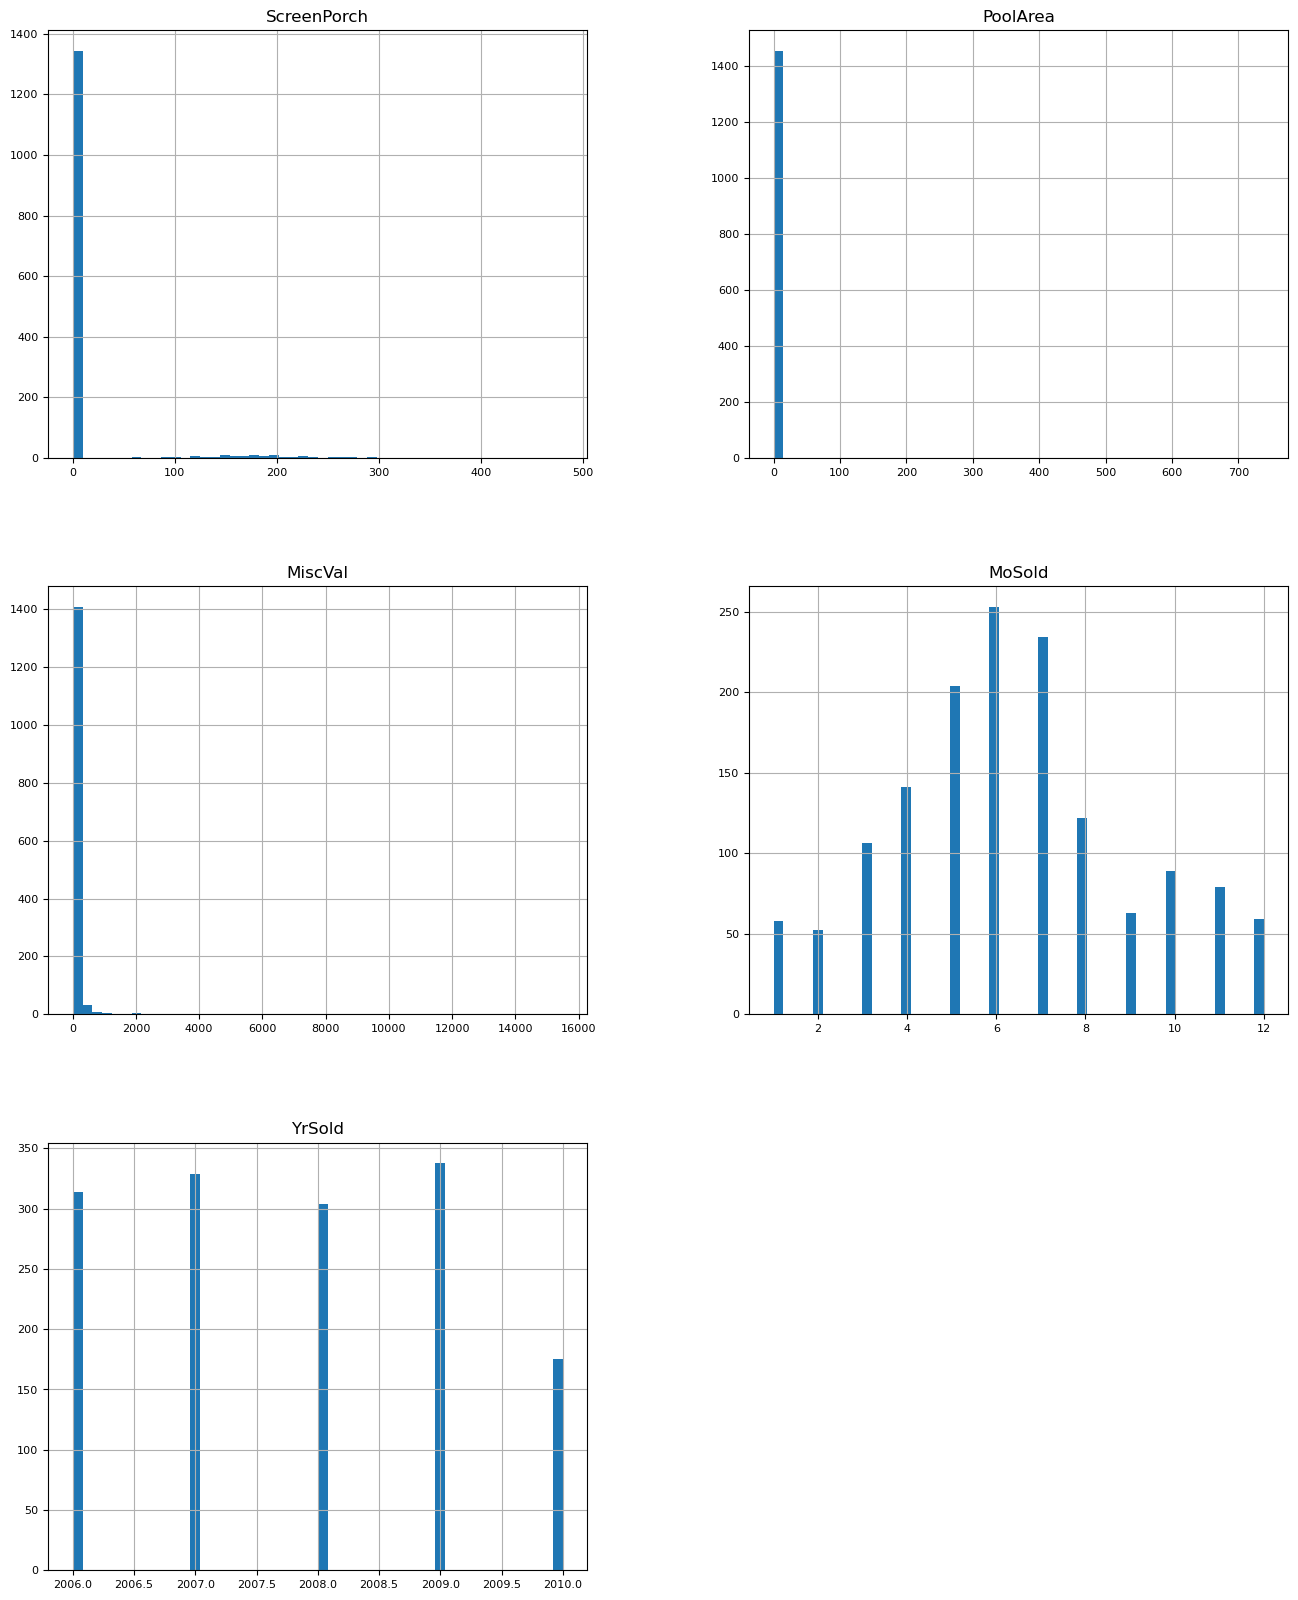

In [902]:
data_numerical_set_4 = data[['ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']]
data_numerical_set_4.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8);
# plt.savefig("picture5.png")

In [903]:
# Cheking for missing values
data.iloc[:, 0:50].isna().sum().sort_values(ascending=False)

Alley           1369
MasVnrType       872
LotFrontage      259
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
TotalBsmtSF        0
BsmtFinSF1         0
BsmtFinSF2         0
BsmtUnfSF          0
HeatingQC          0
Heating            0
ExterCond          0
CentralAir         0
1stFlrSF           0
2ndFlrSF           0
LowQualFinSF       0
GrLivArea          0
BsmtFullBath       0
BsmtHalfBath       0
FullBath           0
Foundation         0
MSSubClass         0
ExterQual          0
Condition2         0
LotArea            0
Street             0
LotShape           0
LandContour        0
Utilities          0
LotConfig          0
LandSlope          0
Neighborhood       0
Condition1         0
BldgType           0
MSZoning           0
HouseStyle         0
OverallQual        0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
RoofStyle          0
RoofMatl           0
Exterior1st  

In [904]:
data.iloc[:, 50:81].isna().sum().sort_values(ascending=False)

PoolQC           1453
MiscFeature      1406
Fence            1179
FireplaceQu       690
GarageFinish       81
GarageCond         81
GarageType         81
GarageYrBlt        81
GarageQual         81
PoolArea            0
BedroomAbvGr        0
MiscVal             0
3SsnPorch           0
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
ScreenPorch         0
WoodDeckSF          0
EnclosedPorch       0
OpenPorchSF         0
KitchenAbvGr        0
PavedDrive          0
GarageArea          0
GarageCars          0
Fireplaces          0
Functional          0
TotRmsAbvGrd        0
KitchenQual         0
SalePrice           0
dtype: int64

In [905]:
# Filling NA's

fill_dict = {'For Garage': 'NoGrg', 'For Basement': 'NoBsmt', 'For Alley': 'NoAcc', 'For Pool': 'NoPool', 'For Masonry': 'None', 'For MiscFeat': 'NoMiscFt', 'For Fireplace': 'NoFrPl', 'For Fence': 'NoFence'}

data['Alley'] = data['Alley'].fillna(fill_dict['For Alley'])
data['MasVnrType'] = data['MasVnrType'].fillna(fill_dict['For Masonry'])
data['LotFrontage'] = data['LotFrontage'].fillna(0)
data['BsmtExposure'] = data['BsmtExposure'].fillna(fill_dict['For Basement'])
data['BsmtFinType2'] = data['BsmtFinType2'].fillna(fill_dict['For Basement'])
data['BsmtQual'] = data['BsmtQual'].fillna(fill_dict['For Basement'])
data['BsmtCond'] = data['BsmtCond'].fillna(fill_dict['For Basement'])
data['BsmtFinType1'] = data['BsmtFinType1'].fillna(fill_dict['For Basement'])
data['MasVnrArea'] = data['MasVnrArea'].fillna(0)
data['PoolQC'] = data['PoolQC'].fillna(fill_dict['For Pool'])
data['MiscFeature'] = data['MiscFeature'].fillna(fill_dict['For MiscFeat'])
data['Fence'] = data['Fence'].fillna(fill_dict['For Fence'])
data['FireplaceQu'] = data['FireplaceQu'].fillna(fill_dict['For Fireplace'])
data['GarageFinish'] = data['GarageFinish'].fillna(fill_dict['For Garage'])
data['GarageCond'] = data['GarageCond'].fillna(fill_dict['For Garage'])
data['GarageType'] = data['GarageType'].fillna(fill_dict['For Garage'])
data['GarageYrBlt'] = data['GarageYrBlt'].fillna(data['GarageYrBlt'].median())
data['GarageQual'] = data['GarageQual'].fillna(fill_dict['For Garage'])
data = data.dropna(subset=['Electrical'])
data.isna().sum().sort_values(ascending=False)

MSSubClass     0
MSZoning       0
GarageYrBlt    0
GarageType     0
FireplaceQu    0
              ..
MasVnrArea     0
MasVnrType     0
Exterior2nd    0
Exterior1st    0
SalePrice      0
Length: 80, dtype: int64

In [906]:
data.shape # Checking if only one row (for "Electrical" == NaN) was dropped.

(1459, 80)

In [907]:
# Splitting the general dataset to training and test sets.
data_for_training = data[0:1001]
data_for_testing = data[1001:1459]
print(data_for_training.tail(4)) # Checkin if splitting went as intended
print(data_for_testing.tail(4))

      MSSubClass MSZoning  LotFrontage  LotArea Street  Alley LotShape  \
997           20       RL          0.0    11717   Pave  NoAcc      IR1   
998           30       RM         60.0     9786   Pave  NoAcc      Reg   
999           20       RL         64.0     6762   Pave  NoAcc      Reg   
1000          20       RL         74.0    10206   Pave  NoAcc      Reg   

     LandContour Utilities LotConfig  ... PoolArea  PoolQC    Fence  \
997          Lvl    AllPub    Inside  ...        0  NoPool  NoFence   
998          Lvl    AllPub    Inside  ...        0  NoPool  NoFence   
999          Lvl    AllPub    Inside  ...        0  NoPool  NoFence   
1000         Lvl    AllPub    Corner  ...        0  NoPool  NoFence   

     MiscFeature MiscVal MoSold  YrSold  SaleType  SaleCondition  SalePrice  
997     NoMiscFt       0      2    2009        WD         Normal     185000  
998     NoMiscFt       0      5    2006        WD         Normal      91000  
999     NoMiscFt       0      2    2010

In [908]:
# Preparing the dataset for model building
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler


ohe = OneHotEncoder(drop='first')
ohe.fit(data_for_training[['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish',  'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']])

X_categorical = ohe.transform(data_for_training[['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish',  'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']]).toarray()

sc = StandardScaler()
sc.fit(data_for_training[['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea','BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']])
X_numerical = sc.transform(data_for_training[['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea','BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']])

y = data_for_training['SalePrice']
X = np.concatenate([X_numerical, X_categorical], axis=1)

X.shape

(1001, 239)

In [909]:
# Training the model and looking at MSE (mean squared error)
lr = LinearRegression()
lr.fit(X, y)
y_pred  = lr.predict(X)
mean_squared_error(y, y_pred)

405955872.60639364